# Bài tập Buổi 5 — Pipeline Machine Learning: EDA & Tiền xử lý trên Titanic

**Khóa học hè 2026 — Python & Machine Learning · ML IoT Lab, HCMUT**

---

## Bối cảnh

Bạn vừa nhận được dataset **Titanic** — danh sách hành khách và việc họ có sống sót sau thảm họa hay không.
Nhiệm vụ của bạn **không phải** huấn luyện mô hình, mà là hoàn thành **hai bước đầu và quan trọng nhất** của một dự án Machine Learning:

> **Khám phá dữ liệu (EDA) → Tiền xử lý dữ liệu.**

Đây là phần chiếm ~70–90% công sức thực tế của một dự án ML. Một mô hình mạnh không thể cứu một bộ dữ liệu kém chất lượng.

## Mục tiêu bài tập

Sau khi hoàn thành, bạn sẽ chứng minh được rằng mình có thể:

1. Thực hiện **EDA đầy đủ** trên một dataset thực tế: kiểm tra cấu trúc, giá trị thiếu, outlier, phân phối và tương quan.
2. **Trực quan hóa** dữ liệu và **rút ra nhận xét có căn cứ** (không chỉ vẽ hình cho đẹp).
3. Áp dụng **đúng kỹ thuật tiền xử lý** cho từng loại dữ liệu: xử lý missing, encoding, scaling.
4. Chia tập và xây pipeline tiền xử lý **không rò rỉ dữ liệu (data leakage)**.
5. Viết **nhận xét tổng hợp** về dữ liệu như một data analyst thực thụ.

## Yêu cầu nộp bài

- Hoàn thiện notebook này (điền vào tất cả các ô `# TODO` và các phần *"Trả lời:"*).
- Notebook phải **chạy được từ trên xuống dưới không lỗi** (Kernel → Restart & Run All).
- Nộp qua **GitHub**: tải repo mẫu → đưa lên repo cá nhân → làm bài và nộp trên đó.

## Tiêu chí chấm (10 điểm)

| Nội dung | Điểm |
|---|---|
| EDA đầy đủ (shape/info/missing/outlier) | 2.0 |
| Trực quan hóa + nhận xét cho mỗi biểu đồ | 2.0 |
| Xử lý missing & outlier hợp lý, có giải thích | 1.5 |
| Encoding & scaling đúng loại biến | 1.5 |
| Chia tập & tiền xử lý **không leakage** | 1.5 |
| Nhận xét tổng hợp về dữ liệu | 1.5 |

> **Lưu ý về liêm chính học thuật:** được tham khảo tài liệu, nhưng phải **tự viết code và tự hiểu**. Phần nhận xét phải là quan sát của chính bạn từ dữ liệu.

---


## 0. Chuẩn bị môi trường

Ô này đã viết sẵn — chạy để nạp thư viện. Nếu thiếu thư viện, cài bằng `pip install pandas numpy matplotlib seaborn scikit-learn`.

In [149]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


## 1. Tải dữ liệu (đã cho)

Ô này đã viết sẵn. Dữ liệu được tải từ `seaborn`, có fallback tải từ Internet nếu cần.

In [150]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()

Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## Task 1 — Loại bỏ cột rò rỉ nhãn (data leakage) và cột dư thừa

### Mục đích
Trên slide đã học: **data leakage** là khi thông tin không được phép "rò" vào mô hình, khiến kết quả đẹp trên giấy nhưng vô dụng thực tế. Bản Titanic của seaborn chứa sẵn nhiều cột **rò rỉ nhãn** hoặc **trùng lặp**:

- `alive` (yes/no) — chính là `survived` viết bằng chữ ⇒ **rò rỉ target trực tiếp**. Để lại là mô hình "gian lận".
- `who`, `adult_male`, `class` — được suy ra từ `sex`, `age`, `pclass` (trùng thông tin).
- `deck` — thiếu quá nhiều (~77%).
- `embark_town` — trùng `embarked`; `alone` — suy ra từ `sibsp` + `parch`.

### Yêu cầu
1. In ra danh sách cột và tỷ lệ missing của **toàn bộ** dataframe (để thấy `deck` thiếu bao nhiêu).
2. Loại bỏ các cột rò rỉ / dư thừa ở trên, chỉ giữ lại:
   `survived, pclass, sex, age, sibsp, parch, fare, embarked`.
3. **Trả lời** (markdown ô dưới): vì sao để lại cột `alive` sẽ khiến mô hình đạt accuracy ~100% mà không thực sự học được gì?

### Gợi ý
- `df.isnull().mean()` cho tỷ lệ thiếu theo cột.
- `df.drop(columns=[...])` để bỏ cột.

In [151]:
# TODO 1a: in tỷ lệ missing của tất cả các cột
missing_ratio = df.isnull().mean()
print("Tỷ lệ missing: ")
print(missing_ratio)

# TODO 1b: bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
leaky = ['alive', 'adult_male', 'who', 'class', 'deck', 'embark_town', 'alone']      # điền danh sách cột cần bỏ (chỉ những cột có trong df)
df = df.drop(columns=leaky, errors='ignore')

print("Các cột còn lại:", list(df.columns))

Tỷ lệ missing: 
survived       0.000000
pclass         0.000000
sex            0.000000
age            0.198653
sibsp          0.000000
parch          0.000000
fare           0.000000
embarked       0.002245
class          0.000000
who            0.000000
adult_male     0.000000
deck           0.772166
embark_town    0.002245
alive          0.000000
alone          0.000000
dtype: float64
Các cột còn lại: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


**Trả lời 1c (vì sao `alive` gây rò rỉ target):**

`alive` (yes/no) — chính là `survived` (0/1) dưới dạng chữ → **rò rỉ target trực tiếp**. Nên nếu để lại mô hình sẽ dễ dàng biết được quy luật: `alive` là "yes" thì `survived` là 1, `alive` là "no" thì `survived` là 0. Lúc đó trên tập test có sẵn cột `alive`, vì thế mô hình đạt accuracy 100% mà "không học gì". 

---
## Task 2 — Quan sát tổng quan

### Mục đích
Trước khi phân tích sâu, phải nắm được "hình dạng" của dữ liệu: bao nhiêu mẫu, bao nhiêu đặc trưng, kiểu dữ liệu từng cột, và thống kê cơ bản. Đây là bước đầu tiên của mọi EDA.

### Yêu cầu
1. In **số dòng và số cột**; nêu rõ đâu là **biến mục tiêu (target)**.
2. Dùng `df.info()` để xem kiểu dữ liệu và số giá trị non-null.
3. Dùng `df.describe()` cho biến số và `df.describe(include="object")` (hoặc `"category"`) cho biến phân loại.
4. **Trả lời:** cột nào là biến **số**, cột nào là biến **phân loại**?

In [152]:
# TODO 2: shape, info, describe
#in số dòng và số cột
print("(Số dòng, số cột): ", df.shape)
print(f"Biến mục tiêu (target): {df.columns[0]}")
print("-" * 50)

#xem kiểu dữ liệu và số giá trị non-full
print("Thông tin cấu trúc dữ liệu: ")
df.info()
print("-"*50)

#
print("Thống kê các biến số: ")
display(df.describe())
print("-"*50)

print("Thống kê các biến phân loại: ")
display(df.describe(include=["object", "category"]))

(Số dòng, số cột):  (891, 8)
Biến mục tiêu (target): survived
--------------------------------------------------
Thông tin cấu trúc dữ liệu: 
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    str    
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 55.8 KB
--------------------------------------------------
Thống kê các biến số: 


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


--------------------------------------------------
Thống kê các biến phân loại: 


C:\Users\HP\AppData\Local\Temp\ipykernel_4452\3807865158.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include=["object", "category"]))


,sex,embarked
count,891,889
unique,2,3
top,male,S
freq,577,644


**Trả lời 2 (biến số vs biến phân loại):**
- Biến số: `age`, `fare`, `sibsp`, `parch`.
- Biến phân loại: `sex`, `embarked`, `pclass` (phân loại hạng vé)

---
## Task 3 — Missing Value: thống kê & đề xuất cách xử lý

### Mục đích
Mô hình học máy **không nhận trực tiếp giá trị NaN**. Nhưng cách xử lý phụ thuộc **tỷ lệ thiếu** và **vai trò của cột** — không có một cách đúng cho mọi trường hợp.

### Yêu cầu
1. Lập bảng: mỗi cột còn missing → **số lượng** và **phần trăm** thiếu.
2. Với **từng cột** còn thiếu, **đề xuất** cách xử lý và **giải thích ngắn gọn** (xóa / điền mean / điền median / điền mode / KNN...).

### Gợi ý
- Nhắc lại từ slide: `median` bền vững hơn `mean` khi có outlier; cột thiếu quá nhiều (>~60–70%) thường nên **bỏ**; biến phân loại thường điền **mode**.

In [153]:
# TODO 3: bảng missing (count + %)
# số lượng giá trị thiếu của từng cột
missing_count = df.isnull().sum()

# phần trăm thiếu của từng cột
missing_percent = df.isnull().mean() * 100

missing_table = pd.DataFrame({'Số lượng thiếu' : missing_count,
                              'Phần trăm thiếu (%)' : missing_percent})

missing_table = missing_table[missing_table['Số lượng thiếu'] > 0]
print("Bảng thống kê các cột thiếu dữ liệu:")
display(missing_table)

Bảng thống kê các cột thiếu dữ liệu:


,Số lượng thiếu,Phần trăm thiếu (%)
age,177,19.865320
embarked,2,0.224467


**Trả lời 3 (đề xuất xử lý cho từng cột thiếu):**

| Cột | % thiếu | Cách xử lý đề xuất | Lý do |
| :--- | :---: | :--- | :--- |
| age | ~19.87% | Điền bằng median| Phần trăm thiếu không quá lớn nên có thể giữ lại và điền khuyết. Chọn median vì ít ảnh hưởng bởi các giá trị lệch hoặc outlier. Do ở Task 2, ta thấy mean của `age` ~29.69, giá trị median là 28, min = 0.42, max = 80 cho thấy dữ liệu có dấu hiệu lệch. |
| embarked | ~0.22% | Điền bằng mode | Phần trăm thiếu cực kì thấp. Vì là biến phân loại nên chọn điền bằng giá trị xuất hiện nhiều nhất. |

---
## Task 4 — Phát hiện Outlier & **ra quyết định**

### Mục đích
Outlier có thể là **lỗi nhập liệu** (cần xử lý) hoặc **hiện tượng thật** (cần giữ). Phát hiện thôi chưa đủ — một analyst giỏi phải **quyết định** làm gì và giải thích được.

### Yêu cầu
1. Trên hai cột `age` và `fare`, đếm số outlier bằng **cả hai** phương pháp: **IQR** và **Z-score** (ngưỡng |z| > 3).
2. **Trả lời:** với các outlier của `fare`, bạn **giữ lại hay loại bỏ**? Vì sao? (gợi ý: nghĩ xem vé đắt bất thường là lỗi hay là vé hạng nhất có thật).

### Gợi ý
- IQR: outlier là điểm ngoài khoảng `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
- Z-score: `from scipy import stats; np.abs(stats.zscore(series.dropna()))`.

In [154]:
# TODO 4: đếm outlier theo IQR và Z-score cho 'age' và 'fare'

from  scipy import stats

def dem_outlier_iqr(s):
    # trả về số lượng outlier theo IQR
    s_clean = s.dropna()

    q1 = s_clean.quantile(0.25)
    q3 = s_clean.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5*iqr
    upper_bound = q3 + 1.5*iqr

    return ((s_clean < lower_bound) | (s_clean > upper_bound)).sum()

def dem_outlier_zscore(s, nguong=3.0):
    # trả về số lượng outlier theo Z-score
    s_clean = s.dropna()

    z_scores = np.abs(stats.zscore(s_clean))

    return (z_scores > nguong).sum()


for col in ["age", "fare"]:
    out_iqr = dem_outlier_iqr(df[col])
    out_z = dem_outlier_zscore(df[col])
    print(f"Cột '{col}':")
    print(f"Số lượng outlier theo IQR: {out_iqr}")
    print(f"Số lượng outlier theo Z-score (ngưỡng 3.0): {out_z}")

Cột 'age':
Số lượng outlier theo IQR: 11
Số lượng outlier theo Z-score (ngưỡng 3.0): 2
Cột 'fare':
Số lượng outlier theo IQR: 116
Số lượng outlier theo Z-score (ngưỡng 3.0): 20


**Trả lời 4 (quyết định với outlier của `fare`):**
Các giá trị vé cao bất thường không phải là lỗi mà là vé hạng nhất có thật. Từ đó vị trí khoang ở có thể liên quan đến cơ hội cứu sống và khả năng sống sót. Do đó không thể xoá bỏ các outlier.

---
## Task 5 — Trực quan hóa & nhận xét

### Mục đích
EDA là môn học về **nhìn** dữ liệu. Mỗi biểu đồ phải trả lời một câu hỏi và **đi kèm một nhận xét**. Vẽ mà không nhận xét thì không tính điểm.

### Yêu cầu — vẽ tối thiểu 4 loại biểu đồ, mỗi biểu đồ 1–2 câu nhận xét:
1. **Univariate — Histogram**: phân phối của `age` và `fare`. (Nhận xét: có lệch không? lệch trái hay phải?)
2. **Univariate — Boxplot**: `fare` theo nhóm `survived` hoặc `pclass`. (Nhận xét: outlier, trung vị.)
3. **Bivariate — Bar/Barplot**: **tỷ lệ sống sót** theo `sex` và theo `pclass`. (Nhận xét: nhóm nào sống nhiều hơn, chênh bao nhiêu %?)
4. **Multivariate — Heatmap**: ma trận tương quan giữa các biến số. (Nhận xét: cặp biến nào tương quan mạnh?)

### Gợi ý
- `sns.histplot`, `sns.boxplot`, `sns.barplot(data=df, x="sex", y="survived")` (barplot tự tính trung bình = tỷ lệ sống sót), `sns.heatmap(df.select_dtypes("number").corr(), annot=True)`.

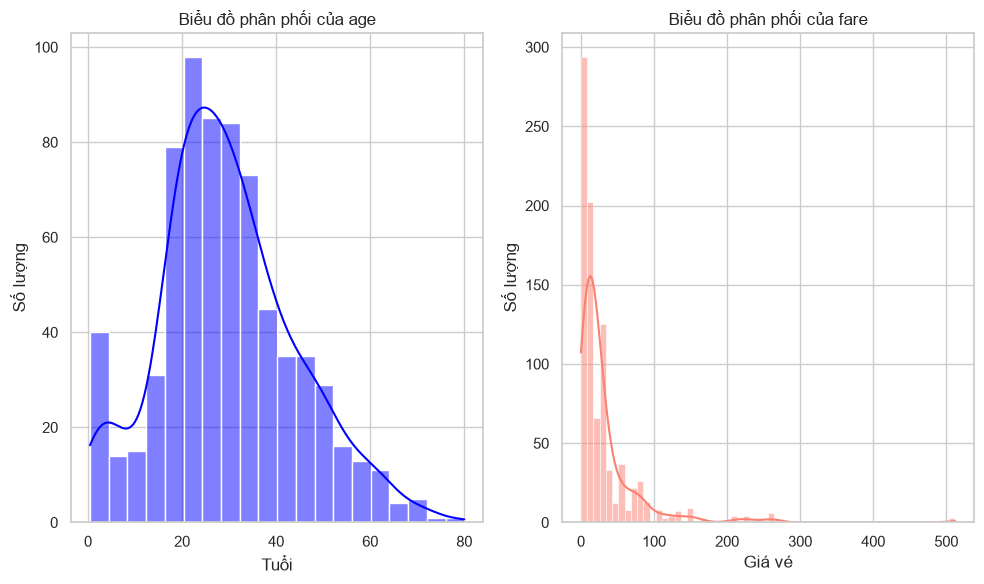

In [155]:
# TODO 5a: Histogram age & fare
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,6))

sns.histplot(data=df, x="age", kde=True, ax=axes[0], color="blue")
axes[0].set_title("Biểu đồ phân phối của age")
axes[0].set_xlabel("Tuổi")
axes[0].set_ylabel("Số lượng")

sns.histplot(data=df, x="fare", kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Biểu đồ phân phối của fare")
axes[1].set_xlabel("Giá vé")
axes[1].set_ylabel("Số lượng")

plt.tight_layout()
plt.show()

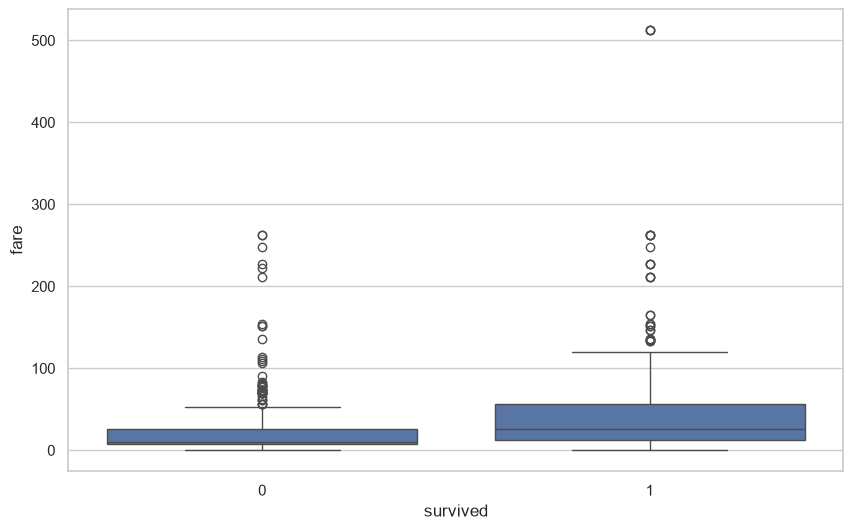

In [156]:
# TODO 5b: Boxplot fare theo survived hoặc pclass
plt.figure(figsize=(10,6))

sns.boxplot(data=df, x="survived", y="fare")
axes[0].set_title("Biểu đồ hộp fare theo survived")
axes[0].set_xlabel("Sống sót (0 = Không, 1 = Có)")
axes[0].set_ylabel("fare")

plt.show()

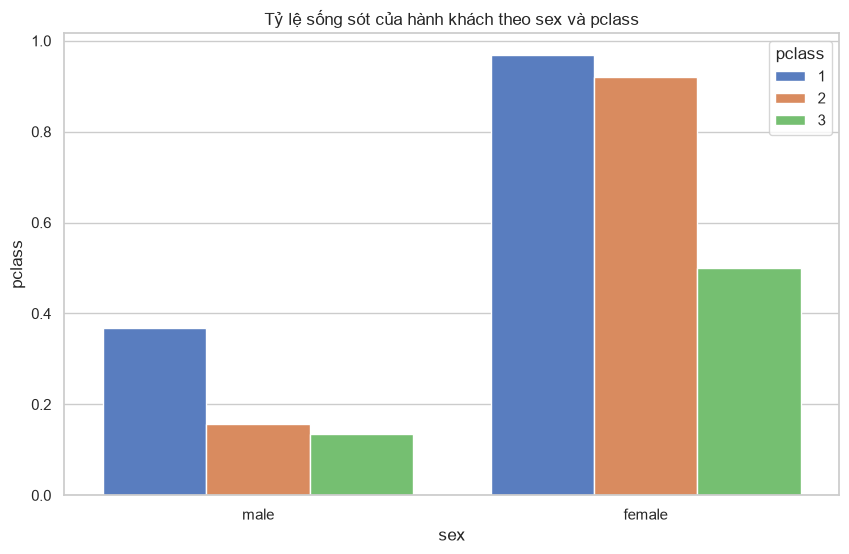

In [157]:
# TODO 5c: Barplot tỷ lệ sống sót theo sex và pclass
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df, 
    x="sex", 
    y="survived", 
    hue="pclass", 
    palette="muted", 
    errorbar=None
)

plt.title("Tỷ lệ sống sót của hành khách theo sex và pclass")
plt.xlabel("sex")
plt.ylabel("pclass")

plt.show()

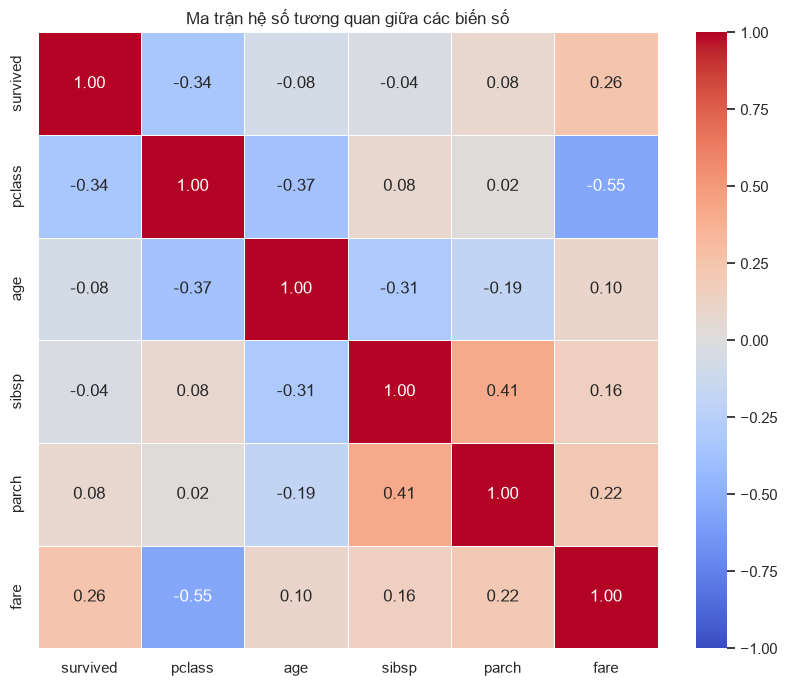

In [158]:
# TODO 5d: Heatmap correlation
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix, 
    annot=True,       
    cmap="coolwarm",  
    fmt=".2f",        
    linewidths=0.5,   
    vmin=-1,          
    vmax=1            
)

plt.title("Ma trận hệ số tương quan giữa các biến số")

plt.show()

**Nhận xét 5 (viết cho từng biểu đồ ở trên):**

- Histogram: 
    + Phân phối của biến `age` tương đối cân đối, tập trung từ 20 đến 40 tuổi.
    + Phân phối của biến `fare` bị lệch phải nghiêm trọng, phần lớn vé giá từ 0 đến 50 USD được mua nhiều.
- Boxplot: đường trung vị của nhóm sống sót `1` cao hơn so với nhóm không sống sót `0`. Các giá trị outlier thấp chủ yếu xuất hiện ở nhóm không sống sót, các giá trị outlier cao chủ yếu xuất hiện ở nhóm sống sót, cho thấy giá vé càng cao, khả năng sống sót càng lớn.
- Bar survival: `female` có tỷ lệ sống sót cao hơn nhiều so với `male` ở tất cả các hạng vé. Tỷ lệ sống sót từ cao đến thấp lần lượt là 1, 2, 3.
- Heatmap: `pclass` và `fare` có mối tương quan âm mạnh nhất (-0.55), thực tế hạng vé càng cao thì giá vé càng thấp và ngược lại. `sibsp` và `parch` có mối tương quan dương mạnh nhất (0.41) cho thấy hành khách có xu hướng đi theo gia đình

---
## Task 6 — Chia tập **TRƯỚC** khi tiền xử lý (chống data leakage)

### Mục đích
Đây là điểm mấu chốt của buổi học. Mọi phép "học tham số" từ dữ liệu (median để điền, min/max/IQR để scale, danh mục để encode) **chỉ được học từ tập train**. Nếu học từ toàn bộ dữ liệu rồi mới chia, thông tin của tập test đã **rò rỉ** — điểm đánh giá sẽ ảo.

⇒ **Vì vậy phải chia tập TRƯỚC**, rồi mới xử lý.

### Yêu cầu
1. Tách `X` (đặc trưng) và `y` (`survived`).
2. Chia **train / validation / test** theo tỷ lệ khoảng **70 / 15 / 15**, có **`stratify=y`** để giữ nguyên tỷ lệ hai lớp.
3. In shape của 3 tập và **tỷ lệ sống sót** trong mỗi tập (để kiểm tra stratify hoạt động).

### Gợi ý
- Dùng `train_test_split` **hai lần**: lần 1 tách test (15%), lần 2 tách val từ phần còn lại.
- `stratify` nhận vào nhãn tương ứng ở mỗi lần chia.

In [159]:
# TODO 6: chia train/val/test có stratify
X = df.drop(columns="survived")
y = df["survived"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)
for name, yy in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"  tỷ lệ Survived ({name}): {yy.mean():.3f}")

Train: (623, 7) | Val: (134, 7) | Test: (134, 7)
  tỷ lệ Survived (train): 0.384
  tỷ lệ Survived (val): 0.388
  tỷ lệ Survived (test): 0.381


---
## Task 7 — Xây pipeline tiền xử lý, **fit chỉ trên train**

### Mục đích
Gộp toàn bộ bước tiền xử lý vào một `ColumnTransformer` + `Pipeline`, `fit` **một lần trên `X_train`** rồi `transform` cho val/test. Đây là cách chuẩn để **đảm bảo không leakage** và tái sử dụng được.

### Yêu cầu
Xây `preprocess` gồm:

- **Biến số** (`age`, `sibsp`, `parch`, `fare`): `SimpleImputer(median)` → scaler (chọn `RobustScaler` vì `fare` có outlier, hoặc giải thích lựa chọn khác).
- **Biến phân loại** (`sex`, `embarked`): `SimpleImputer(most_frequent)` → `OneHotEncoder`.
- **Biến thứ tự** (`pclass`): giữ nguyên (`passthrough`) vì đã là số có thứ tự 1 < 2 < 3.

Sau đó: `fit` trên `X_train`, `transform` cho cả ba tập; in shape kết quả và tên cột sau biến đổi.

### Yêu cầu trả lời
- **Trả lời:** giải thích vì sao `fit` chỉ trên train (không phải trên toàn bộ dữ liệu) thì tránh được leakage.

### Gợi ý
- Khung `ColumnTransformer([... ("num", pipe_so, num_cols), ("cat", pipe_cat, cat_cols), ("ord", "passthrough", ord_cols)])`.
- `preprocess.get_feature_names_out()` để xem tên cột sau biến đổi.

In [160]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

# TODO 7: xây pipeline cho biến số và biến phân loại
pipe_so  = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  RobustScaler()),
])
pipe_cat = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocess = ColumnTransformer([
    ("num", pipe_so,  num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols),
])

preprocess.fit(X_train)               # fit CHỈ trên train
X_train_t = preprocess.transform(X_train)
X_val_t   = preprocess.transform(X_val)
X_test_t  = preprocess.transform(X_test)
print(X_train_t.shape, list(preprocess.get_feature_names_out()))

(623, 10) ['num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_female', 'cat__sex_male', 'cat__embarked_C', 'cat__embarked_Q', 'cat__embarked_S', 'ord__pclass']


**Trả lời 7 (vì sao fit chỉ trên train tránh leakage):**
Tập validation và tập test dùng để kiểm định và kiểm thử khi mô hình hoạt động. Nếu fit trên toàn bộ dữ liệu trước khi chia fit chung trên cả tập validation hoặc test, thông tin dùng để kiểm định, kiểm tra sẽ vô tình bị trộn lẫn và làm thay đổi các tham số thống kê của tập train. Khiến mô hình học trước các thông tin của tập kiểm thử, dẫn đến kết quả ảo.

---
## Task 8 — Câu hỏi tư duy: chọn metric đánh giá

### Mục đích
Buổi học nhấn mạnh: **không có metric tốt nhất tuyệt đối** — phải chọn theo bài toán và mức mất cân bằng dữ liệu. Bài này không cần code, chỉ cần lập luận.

### Yêu cầu — trả lời ngắn gọn:
1. Biến mục tiêu `survived` có **mất cân bằng** không? (tính tỷ lệ hai lớp để trả lời).
2. Nếu chỉ nhìn **Accuracy**, có thể bị đánh lừa trong trường hợp nào?
3. Với bài toán Titanic, bạn sẽ ưu tiên metric nào (Accuracy / Precision / Recall / F1)? Vì sao?

In [161]:
# TODO 8: tính tỷ lệ hai lớp của 'survived' để hỗ trợ trả lời
counts = y_train.value_counts()

percentages = y_train.value_counts(normalize=True)

print("Phân phối của biến mục tiêu 'survived' trên tập train:")
print(f"Số người không sống sót (Lớp 0): {counts[0]} chiếm {percentages[0]:.2%}")
print(f"Số người sống sót (Lớp 1): {counts[1]} chiếm {percentages[1]:.2%}")

Phân phối của biến mục tiêu 'survived' trên tập train:
Số người không sống sót (Lớp 0): 384 chiếm 61.64%
Số người sống sót (Lớp 1): 239 chiếm 38.36%


**Trả lời 8:**

1. Biến mục tiêu `survived` bị mất cân bằng (lớp 0 chiến 61.64%, lớp 1 chiếm 38.36%)
2. Nếu chỉ nhìn Accuracy sẽ bị đánh lừa nếu dữ liệu mất cân bằng nghiêm trọng. Lúc đó, mô hình chỉ cần dự đoán tất cả mẫu thuộc về lớp chiếm đa số nhưng lại bỏ sót hoàn toàn lớp chiếm thiểu số quan trọng.
3. Ưu tiên sử dụng F1-Score để đánh giá độ chính xác của mô hình phân loại khi dữ liệu bị mất cân bằng vì bài toán cần tối ưu cả 2 yếu tố: Precision (độ chính xác trên những mẫu dự đoán đúng) và Recall (độ bao phủ, tránh bỏ sót mẫu thực tế).

---
## Task 9 — Nhận xét tổng hợp về dữ liệu

### Mục đích
Khép lại toàn bộ EDA bằng một bản tóm tắt như một data analyst gửi cho đồng đội: **những gì đáng chú ý nhất** về bộ dữ liệu này.

### Yêu cầu — viết ít nhất 5 gạch đầu dòng, dựa trên **bằng chứng** (số liệu / biểu đồ) ở trên:
- Đặc trưng nào **tương quan mạnh nhất** với khả năng sống sót? (số liệu chứng minh)
- Cột nào **thiếu nhiều nhất** và bạn đã xử lý thế nào?
- Biến mục tiêu có **mất cân bằng** không? ảnh hưởng gì tới việc chọn metric?
- Đặc trưng nào cần **scaling**, đặc trưng nào cần **encoding**? vì sao?
- Một điều bạn thấy **bất ngờ / thú vị** trong dữ liệu.

**Nhận xét tổng hợp của bạn:**

1. Dựa vào heatmap, đặc trưng tương quan mạnh nhất với khả năng sống sót:
    + `sex` thông qua barplot cho thấy tỷ lệ sống sót của nữ giới cao rất nhiều so với nam giới.
    + `pclass` thông qua heatmap cho thấy mối quan hệ tương quan âm cao với `survived` (-0.34).
2. Cột `deck` chứa tỷ lệ thiếu ~77% và đã bị loại bỏ ngay ở Task 1.
3. Sau tính toán ở Task 8, ta thấy biến mục tiêu `survived` có mất cân bằng (lớp 0 chiến 61.64%, lớp 1 chiếm 38.36%). Do vậy việc đánh giá mô hình không chỉ dựa trên Accuracy mà cần dùng F1-Score để đánh giá chính xác trên cả 2 phương diện.
4. Biến số `age`, `sibsp`, `parch`, `fare` cần áp dụng scalling (dùng `RobustScaler`) vì dựa trên histogram ta thấy thang đo chênh lệch lớn như biến `age` nằm trong khoảng từ 0 đến 80 tuổi, `fare` nằm trong khoảng 0 đến 512 USD, nếu không scale thì mô hình có thể hiểu rằng 512 của giá vé quan trọng hơn rất nhiều so với khoảng cách 80 của tuổi tác, từ đó mô hình thiên vị chỉ tập trung học `fare` mà bỏ qua cột `age`. Và dùng RobustScaler vì dữ liệu có nhiều outlier (`fare` có 116 outlier).
Biến phân loại hoặc dạng chữ `sex`, `embarked` cần áp dụng encoding để chuyển đổi thành dạng máy tính có thể tính toán được.
5. Điều bất ngờ là tỷ lệ nữ giới sống sót lại cao hơn nam giới thông qua barplot. Vì thông thường nghĩ về sức khoẻ, nam giới luôn chiếm ưu thế. Nhưng có lẽ ở đây trong ưu tiên cứu người thì nữ giới được ưu tiên hơn.

---
## (Bonus — không bắt buộc) Thử thách nâng cao

Chọn **một** trong các hướng sau nếu bạn muốn thử sức:

1. **Feature engineering:** tạo đặc trưng mới `family_size = sibsp + parch + 1`, hoặc trích `title` (Mr/Mrs/Miss...) từ tên (nếu dùng bản có cột `name`). Kiểm tra tương quan với `survived`.
2. **So sánh scaler:** vẽ phân phối `fare` trước và sau khi áp `StandardScaler`, `MinMaxScaler`, `RobustScaler`. Nhận xét scaler nào phù hợp nhất với dữ liệu lệch + có outlier.
3. **Bẫy KNN:** thử `KNNImputer` để điền `age` **khi chưa scale** và **sau khi đã scale** `fare`. Quan sát kết quả có khác nhau không, và giải thích tại sao (gợi ý: khoảng cách Euclid bị chi phối bởi cột thang đo lớn).

In [162]:
# (tùy chọn) code cho phần Bonus
...

Ellipsis

---
## Bảng tự kiểm trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không lỗi.
- [ ] Đã bỏ các cột rò rỉ/dư thừa (Task 1) và giải thích được vì sao.
- [ ] Mỗi biểu đồ (Task 5) đều có **nhận xét**.
- [ ] Đã **chia tập trước**, tiền xử lý **fit chỉ trên train** (Task 6–7).
- [ ] Đã trả lời tất cả các phần *"Trả lời:"*.
- [ ] Nhận xét tổng hợp (Task 9) có **ít nhất 5 ý** dựa trên bằng chứng.
- [ ] Đã push lên **repo cá nhân trên GitHub**.
